# Import Libraries

In [1]:
# Basic libraries
import os
import random
import warnings
warnings.filterwarnings('ignore')


# Mathematical Calculation
import numpy as np
import pandas as pd


# Visualization
import seaborn as sns
import matplotlib.pyplot as plt


# Split Data
from sklearn.model_selection import train_test_split


# Deep Learning
import tensorflow as tf


# Deep Learning Model Building Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Activation
)


# Optimizers
from tensorflow.keras.optimizers import (
    Adam,
    RMSprop,
    SGD
)


# Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    TensorBoard
)


# Image Generator
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)


# Transfer learning
from tensorflow.keras.applications import (
    VGG16,
    VGG19,
    ResNet50,
    EfficientNetB0
)

# Dataset
from tensorflow.keras.datasets import cifar10

# Preprocessing
from tensorflow.keras.utils import to_categorical


# Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Date and Time
import datetime

## Load Dataset

In [2]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [3]:
# Check Dataset Shape

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


## Visualize Dataset

In [4]:
# Check Total Classes

unique_classes = np.unique(y_train)
print("Total Classes:", len(unique_classes))

Total Classes: 10


In [5]:
# Check Classes ke naam
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Classes name:")
for i, name in enumerate(class_names):
    print(f"Label {i} -> {name}")


Classes name:
Label 0 -> airplane
Label 1 -> automobile
Label 2 -> bird
Label 3 -> cat
Label 4 -> deer
Label 5 -> dog
Label 6 -> frog
Label 7 -> horse
Label 8 -> ship
Label 9 -> truck


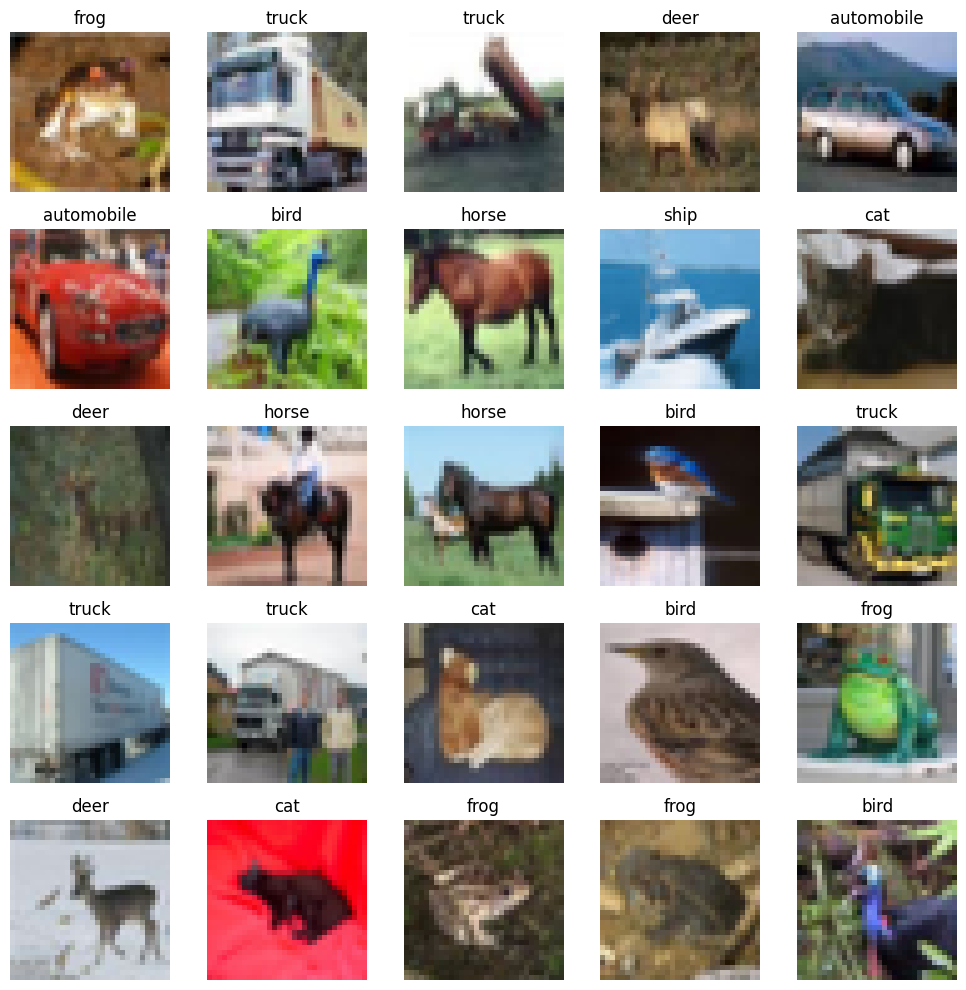

In [6]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## Normalization

In [7]:
# Data Scaling

X_train = X_train / 255.0
X_test = X_test / 255.0

## One Hot Encoding

In [8]:
# Target Encoded

y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

## Data Augmentation

In [9]:
train_datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip = True,
)


train_datagen.fit(X_train)

## Building Advance cnn Model

In [10]:
model = Sequential()


# 1st Convoulation Block
model.add(Conv2D(
    filters = 32,
    kernel_size = (3,3),
    padding = 'same',
    input_shape = (32,32,3),
    activation = 'relu'
    )
)

model.add(BatchNormalization())

model.add(Conv2D(
    filters = 32,
    kernel_size = (3,3),
    padding = 'same',
    activation = 'relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Dropout(0.25))


# 2nd Convolution Block
model.add(Conv2D(
    filters = 64,
    kernel_size = (3,3),
    padding = 'same',
    activation = 'relu'
    )
)

model.add(BatchNormalization())

model.add(Conv2D(
    filters = 64,
    kernel_size = (3,3),
    padding = 'same',
    activation = 'relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Dropout(0.3))


# 3rd Convolution Block
model.add(Conv2D(
    filters = 128,
    kernel_size = (3,3),
    padding = 'same',
    activation = 'relu'
))

model.add(BatchNormalization())

model.add(Conv2D(
    filters = 128,
    kernel_size = (3,3),
    padding = 'same',
    activation = 'relu'
))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Dropout(0.4))


# Classifier Block
model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation = 'relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation = 'softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,394 (1.24 MB)

 Trainable params: 323,498 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

## Compile Model

In [11]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

## Callbacks

In [12]:
# Stop training when Accuracy not Improve.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


# Reduce learning rate when loss not minimize.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001
)


# Save best model in training.
checkpoint = ModelCheckpoint(
    'saved_models/best_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)



log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

## Train Model

In [13]:
history = model.fit(
    train_datagen.flow(
        X_train,
        y_train_encoded,
        batch_size=64
        ),

    validation_data=(X_test, y_test_encoded),

    epochs=50,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint,
        tensorboard
        ]
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 63ms/step - accuracy: 0.4284 - loss: 1.5674 - val_accuracy: 0.5392 - val_loss: 1.2743 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5720 - loss: 1.2100 - val_accuracy: 0.6253 - val_loss: 1.0685 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6343 - loss: 1.0398 - val_accuracy: 0.6783 - val_loss: 0.9299 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.6737 - loss: 0.9435 - val_accuracy: 0.7230 - val_loss: 0.8131 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6984 - loss: 0.8730 - val_accuracy: 0.7030 - val_loss: 0.9081 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7105 - loss: 0.8360 - val_accuracy: 0.7008 - val_loss: 0.9287 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.7250 - l

## Plot Accuracy

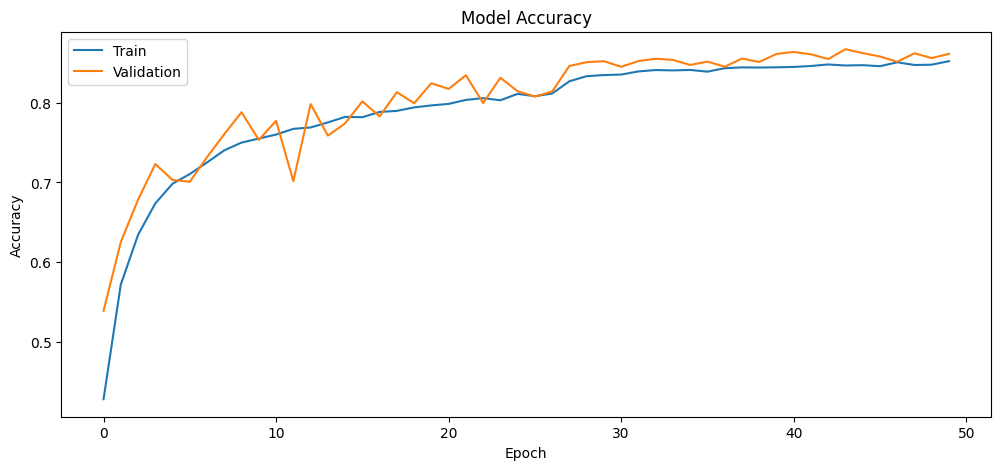

In [24]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

## Plot Loss

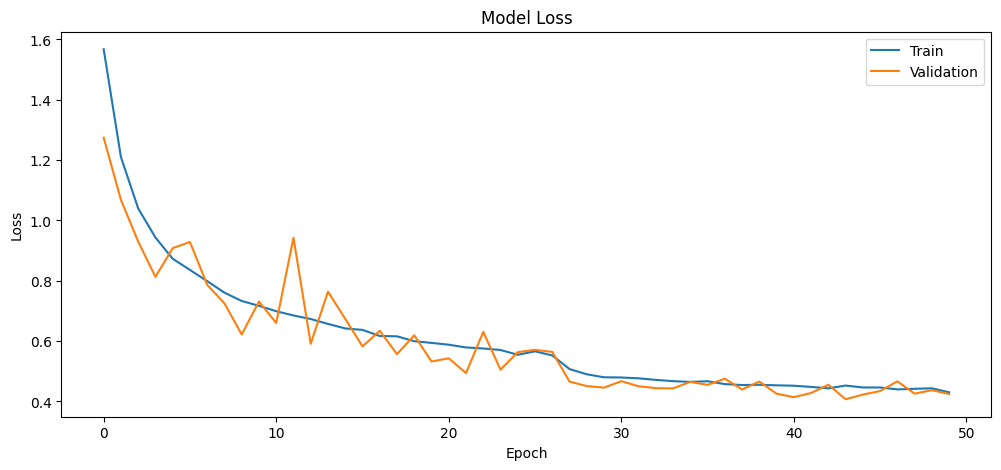

In [26]:
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

## Evaluate Model

In [16]:
loss, accuracy = model.evaluate(X_test, y_test_encoded)

print('Test Loss:', loss)

print('Test Accuracy:', accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8668 - loss: 0.4075
Test Loss: 0.40753233432769775
Test Accuracy: 0.8668000102043152


## Predictions

In [17]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

y_test_flat = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


## Confusion Matrix

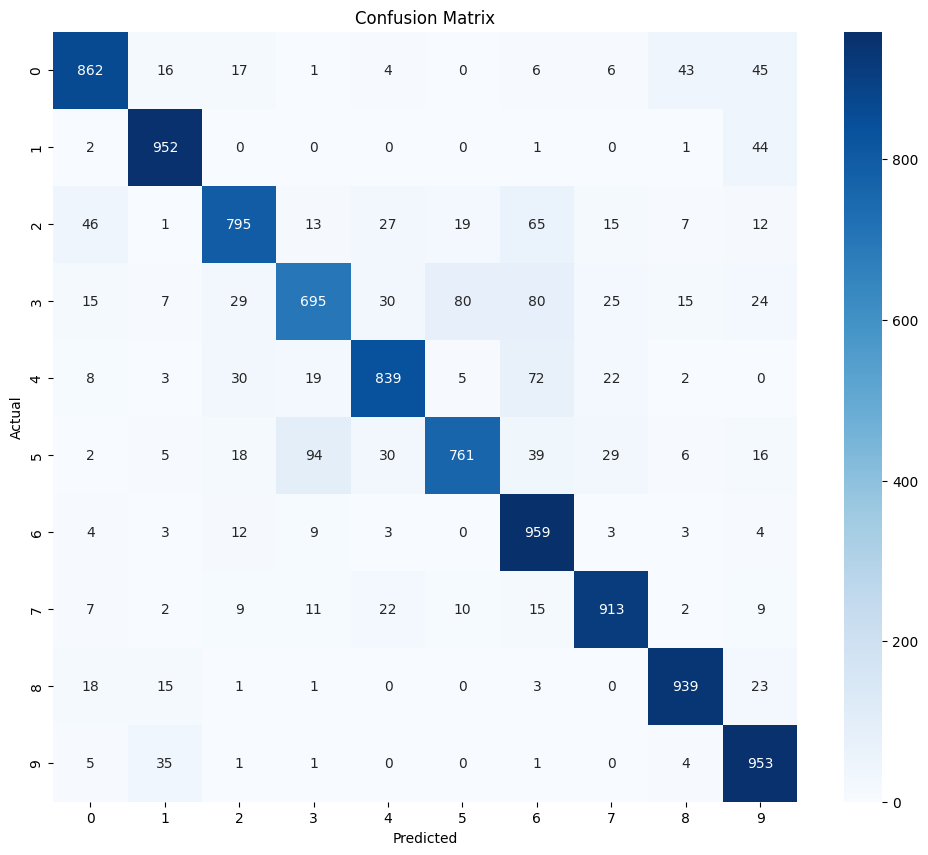

In [18]:
cm = confusion_matrix(
    y_test_flat,
    predicted_labels
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

## Classification report

In [19]:
print(
    classification_report(
        y_test_flat,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.89      0.86      0.88      1000
  automobile       0.92      0.95      0.93      1000
        bird       0.87      0.80      0.83      1000
         cat       0.82      0.69      0.75      1000
        deer       0.88      0.84      0.86      1000
         dog       0.87      0.76      0.81      1000
        frog       0.77      0.96      0.86      1000
       horse       0.90      0.91      0.91      1000
        ship       0.92      0.94      0.93      1000
       truck       0.84      0.95      0.89      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



## Actual vs Predicted

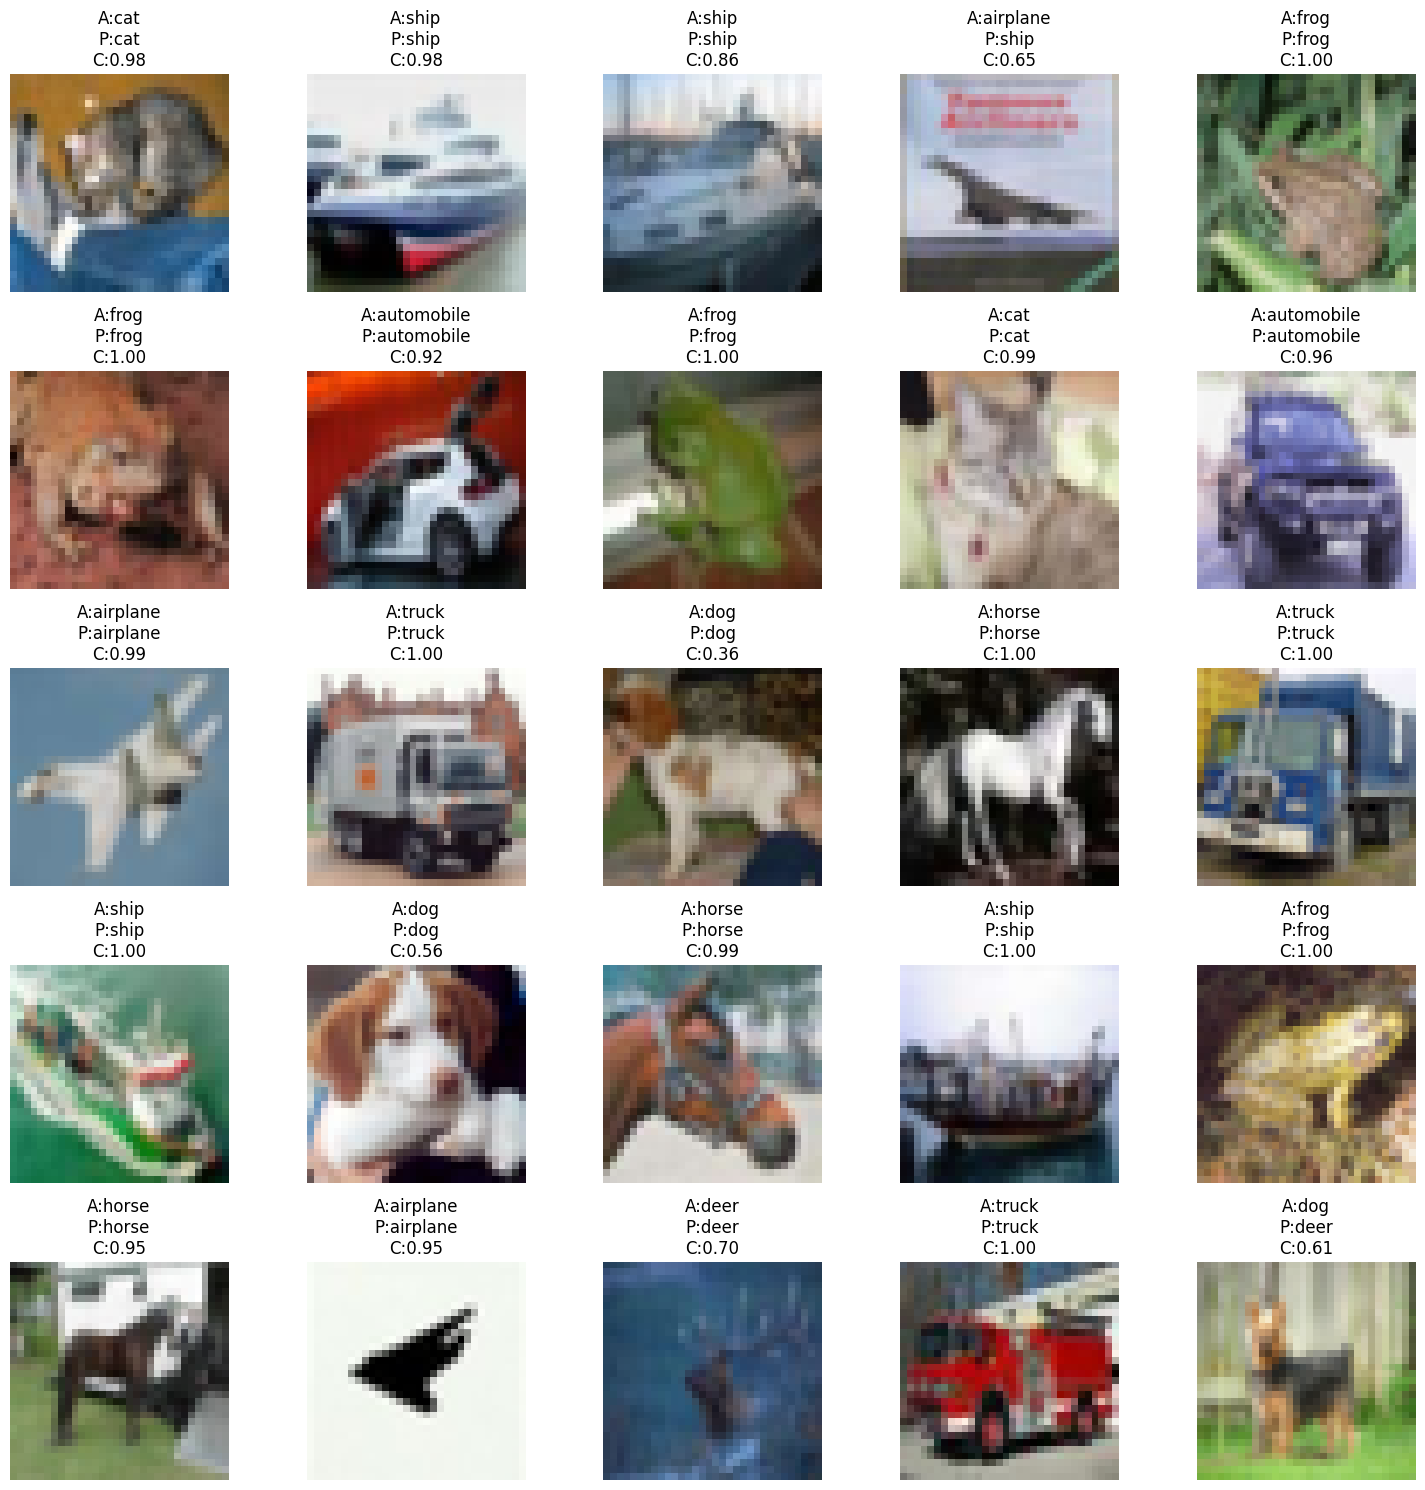

In [20]:
plt.figure(figsize=(15,15))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(X_test[i])

    actual = class_names[y_test_flat[i]]

    predicted = class_names[predicted_labels[i]]

    confidence = np.max(predictions[i])

    plt.title(

        f'A:{actual}\nP:{predicted}\nC:{confidence:.2f}'
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

## Wrong Predictions Analysis

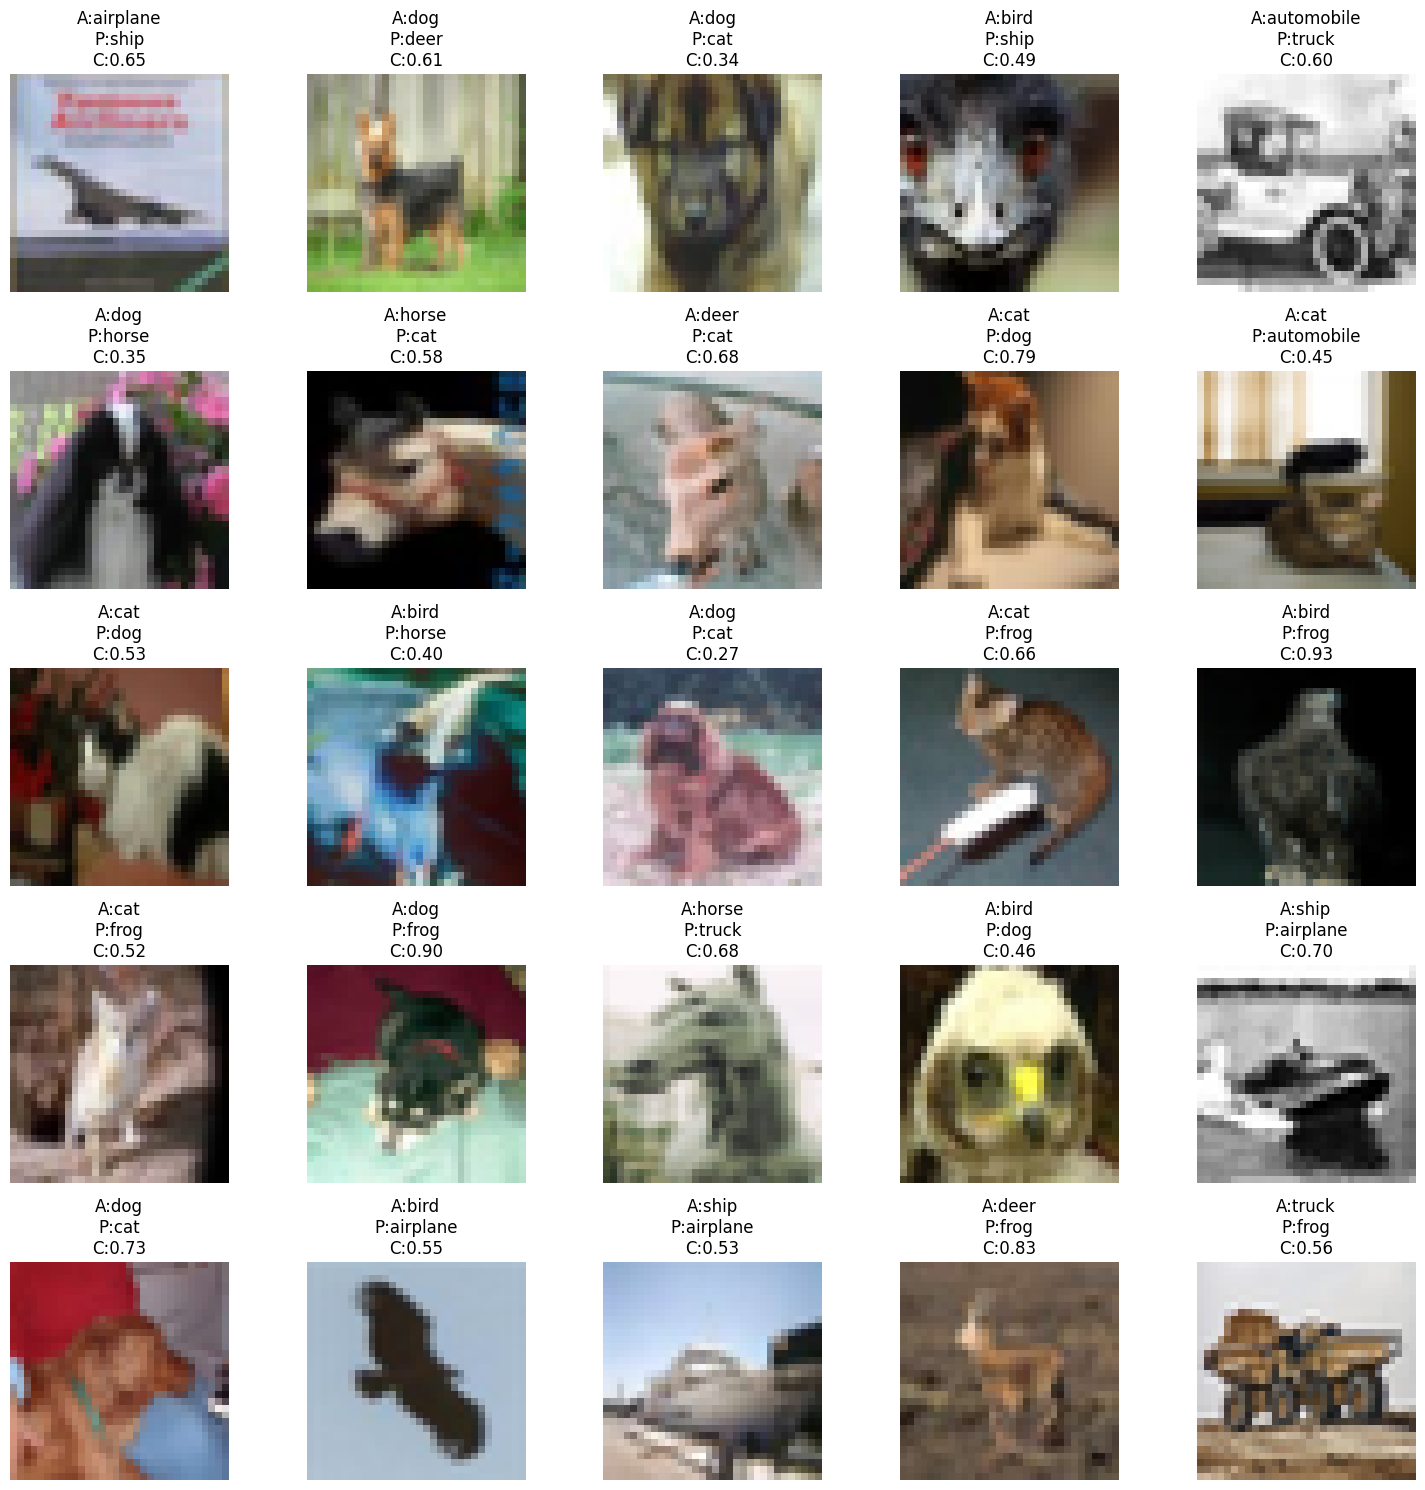

In [21]:
wrong = np.where(
    predicted_labels != y_test_flat
)[0]

plt.figure(figsize=(15,15))

for i, index in enumerate(wrong[:25]):

    plt.subplot(5,5,i+1)

    plt.imshow(X_test[index])

    actual = class_names[y_test_flat[index]]

    predicted = class_names[predicted_labels[index]]

    confidence = np.max(predictions[index])

    plt.title(

        f'A:{actual}\nP:{predicted}\nC:{confidence:.2f}'
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

## Save Model

In [22]:
model.save(
    'saved_models/final_cnn_model.keras'
)

print('Model Saved Successfully')

Model Saved Successfully


## Load Model

In [23]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    'saved_models/final_cnn_model.keras'
)



## Test Model and Visualize Images



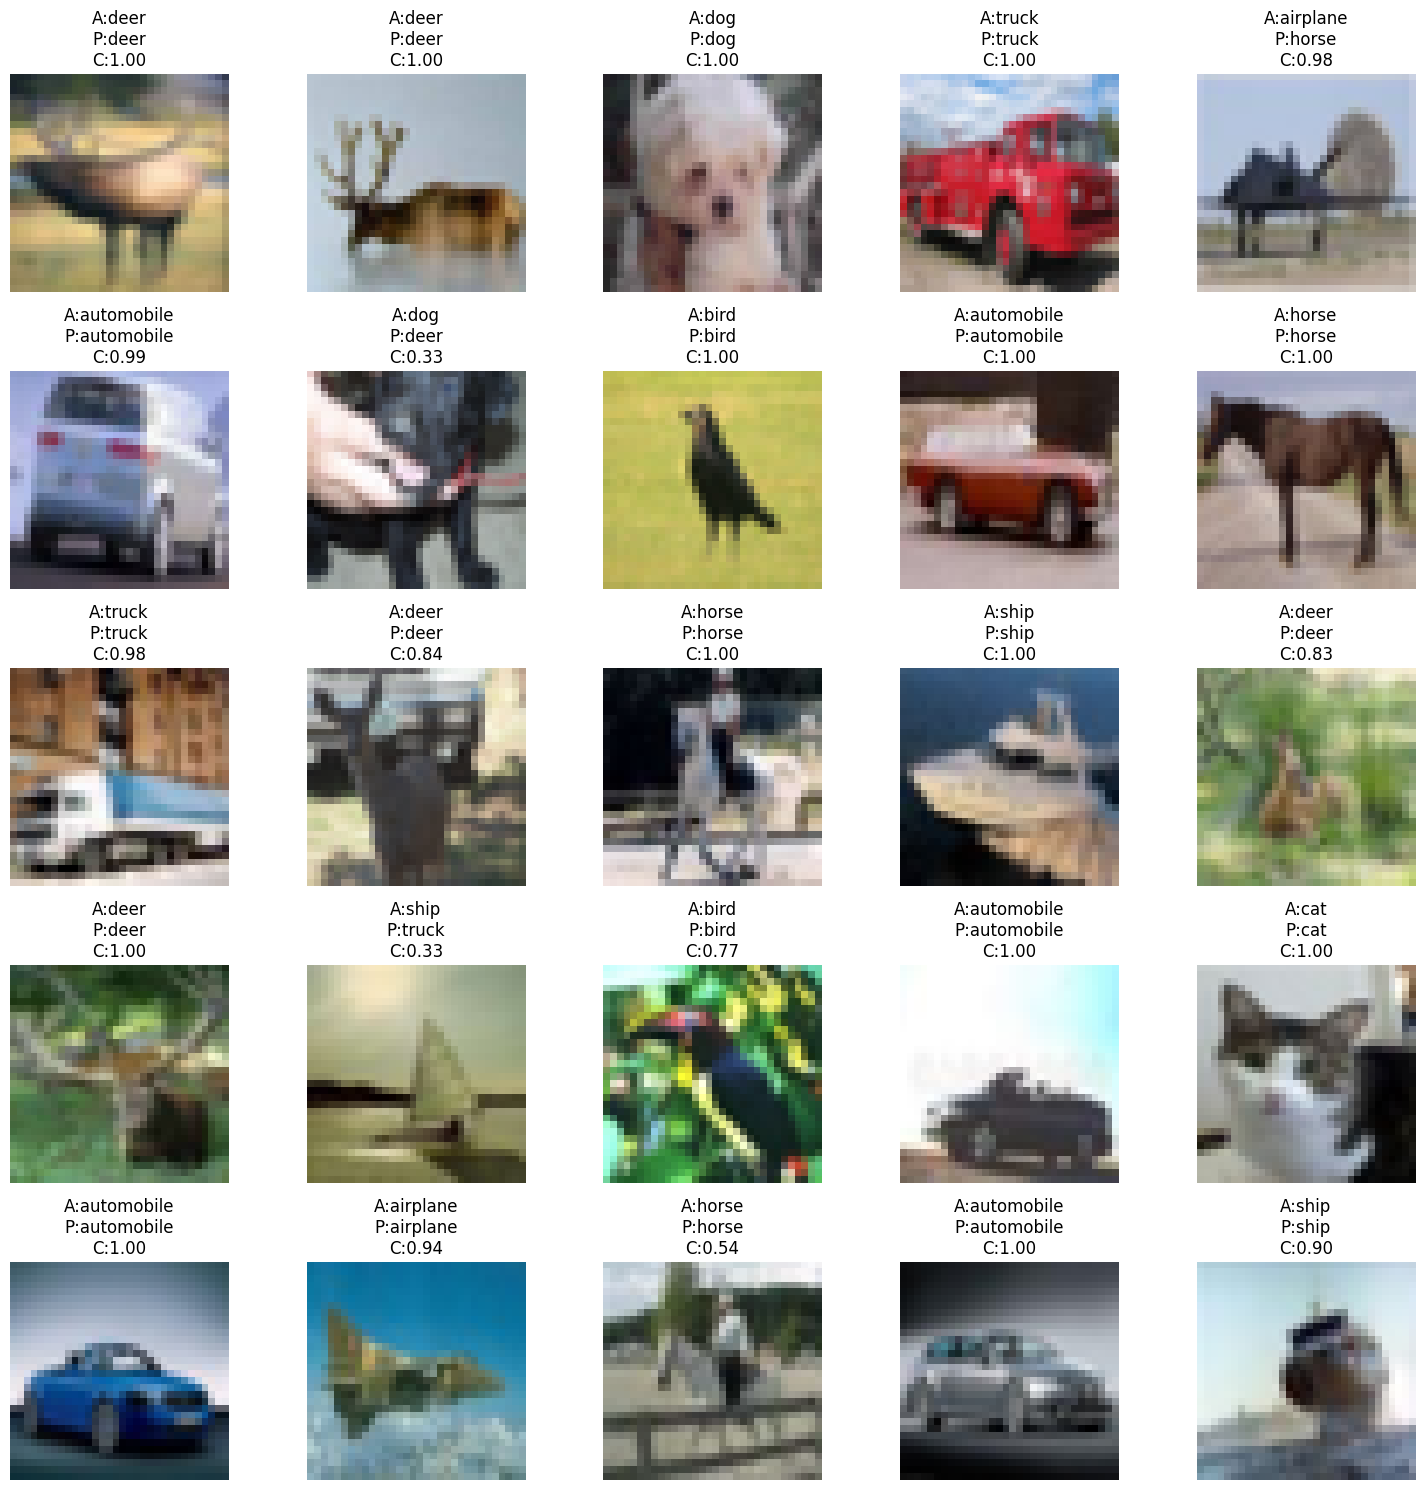

In [27]:
import random

plt.figure(figsize=(15,15))

for i in range(25):

    index = random.randint(0, len(X_test)-1)

    image = X_test[index]

    actual_label = class_names[y_test_flat[index]]

    prediction = loaded_model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_index = np.argmax(prediction)

    predicted_label = class_names[predicted_index]

    confidence = np.max(prediction)

    plt.subplot(5,5,i+1)

    plt.imshow(image)

    plt.title(

        f'A:{actual_label}\n'
        f'P:{predicted_label}\n'
        f'C:{confidence:.2f}'
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

## Prediction Function

In [29]:
def predict_image(model, image, class_names):

    # Expand dimensions
    image_batch = np.expand_dims(image, axis=0)

    # Predict
    prediction = model.predict(
        image_batch,
        verbose=0
    )

    # Get prediction index
    predicted_index = np.argmax(prediction)

    # Get label
    predicted_label = class_names[predicted_index]

    # Confidence
    confidence = np.max(prediction)

    # Visualization
    plt.figure(figsize=(4,4))

    plt.imshow(image)

    plt.title(

        f'Prediction: {predicted_label}\n'
        f'Confidence: {confidence:.2f}'
    )

    plt.axis('off')

    plt.show()

    return predicted_label, confidence

## Test Function

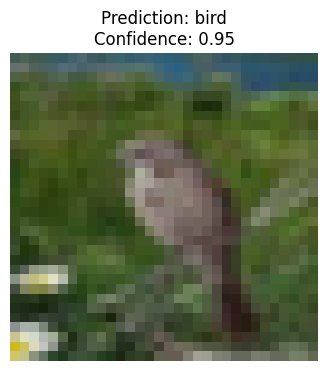

('bird', np.float32(0.9534501))

In [33]:
random_index = random.randint(0, len(X_test)-1)

sample_image = X_test[random_index]

predict_image(
    loaded_model,
    sample_image,
    class_names
)

## Saved Some Image

In [36]:
import os
import cv2

os.makedirs('test_images', exist_ok=True)

for i in range(10):

    image = X_test[i] * 255

    image = image.astype('uint8')

    image_bgr = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(

        f'test_images/image_{i}.jpg',

        image_bgr
    )

print('Images Saved')

Images Saved


## Custom Image Function

In [37]:
import cv2

def predict_custom_image(
    image_path,
    model,
    class_names
):

    # Read image
    image = cv2.imread(image_path)

    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Resize
    resized_image = cv2.resize(
        image_rgb,
        (32,32)
    )

    # Normalize
    normalized_image = resized_image / 255.0

    # Expand dimensions
    image_batch = np.expand_dims(
        normalized_image,
        axis=0
    )

    # Prediction
    prediction = model.predict(
        image_batch,
        verbose=0
    )

    predicted_index = np.argmax(prediction)

    predicted_label = class_names[predicted_index]

    confidence = np.max(prediction)

    # Show image
    plt.figure(figsize=(5,5))

    plt.imshow(image_rgb)

    plt.title(

        f'Prediction: {predicted_label}\n'
        f'Confidence: {confidence:.2f}'
    )

    plt.axis('off')

    plt.show()

    return predicted_label, confidence

## Test image

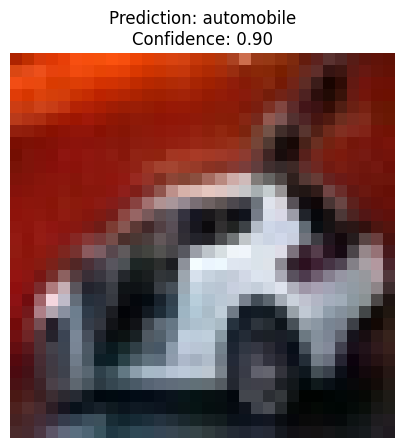

('automobile', np.float32(0.9028605))

In [39]:
predict_custom_image(

    image_path='/content/test_images/image_6.jpg',

    model=loaded_model,

    class_names=class_names
)